In [35]:
# run in yanat_env

from yanat import core, utils as ut
import numpy as np 
import matplotlib.pyplot as plt
import visual_config

In [33]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

from visual_config import NIGHT_BLUE, HALF_PAGE
coordinates_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/00_just_converted_for_matlab_and_python/data_10_consensus/04_coordinates_68.csv"
connectivity_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/01_first_analysises/connectomes_weighted_68x68.npy"

coordinates = pd.read_csv(coordinates_path, header=None) 
connectivity = np.load(connectivity_path)[0,:,:]

AttributeError: module 'yanat.utils' has no attribute 'brain_plotter'

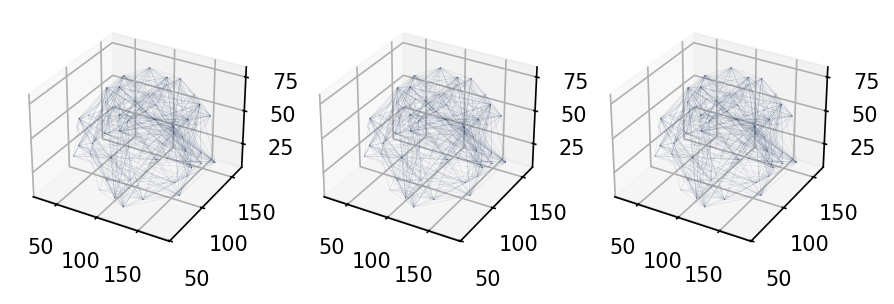

In [36]:
fig, axes = plt.subplot_mosaic(
    [["A", "B", "C"]], figsize=HALF_PAGE, subplot_kw=dict(projection="3d"), dpi=150
)


for i in range(connectivity.shape[0]):
    for j in range(i, connectivity.shape[1]):
        if connectivity[i, j] != 0:
            axes["A"].plot(
                [coordinates[0][i], coordinates[0][j]],
                [coordinates[1][i], coordinates[1][j]],
                [coordinates[2][i], coordinates[2][j]],
                c=NIGHT_BLUE,
                alpha=0.2 + connectivity[i, j],
                linewidth=0.2,
            )
            axes["B"].plot(
                [coordinates[0][i], coordinates[0][j]],
                [coordinates[1][i], coordinates[1][j]],
                [coordinates[2][i], coordinates[2][j]],
                c=NIGHT_BLUE,
                alpha=0.2 + connectivity[i, j],
                linewidth=0.2,
            )
            axes["C"].plot(
                [coordinates[0][i], coordinates[0][j]],
                [coordinates[1][i], coordinates[1][j]],
                [coordinates[2][i], coordinates[2][j]],
                c=NIGHT_BLUE,
                alpha=0.2 + connectivity[i, j],
                linewidth=0.2,
            )

ut.brain_plotter(
    np.array(coordinates[:, 0]),
    coordinates,
    axes["A"],
    view=sagittal,
    size=10,
    cmap=monochrome,
    scatter_kwargs=scatter_kw_network,
)
ut.brain_plotter(
    np.flip(np.array(coordinates[:, 2])),
    coordinates,
    axes["B"],
    view=axial,
    size=10,
    cmap=monochrome,
    scatter_kwargs=scatter_kw_network,
)
ut.brain_plotter(
    np.flip(np.array(coordinates[:, 1])),
    coordinates,
    axes["C"],
    view=coronal,
    size=10,
    cmap=monochrome,
    scatter_kwargs=scatter_kw_network,
)

fig.tight_layout(pad=0.1)
# plt.savefig(f"figures/structural_brain_network.pdf", dpi=600, bbox_inches="tight")

OI Stuff


In [ ]:
# conn_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/23_testing_4_KS_folders/all_generated_networks/23_testing_4_KS_folders_20250930_003937_net_eta-0.880_gamma0.320_ruleMatchingIndex.npy"

# weighted
conn_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/01_first_analysises/connectomes_weighted_68x68.npy"
connectivity = np.load(conn_path)[0,:,:]


connectivity = ut.spectral_normalization(1,connectivity)
plt.figure(figsize=visual_config.TINY, dpi=150)
plt.imshow(connectivity, cmap=visual_config.white_blue_mono) 

In [8]:
NOISE_STRENGTH:float = 1.0 # SD of the Gaussian input noise to each node.
DELTA:float = 0.01 # Time step of the simulation.
TAU:float = 0.01 # Time constant of the local dynamics.
G:float = 0.9 # Coupling strength.
DURATION:float = 10. # Duration of the simulation.

model_params:dict = {"dt": DELTA, "timeconstant": TAU, "coupling": G, "duration": DURATION}

N_NODES:int = connectivity.shape[0] # Number of nodes in the network.
SEED:int = 11 # Random seed for reproducibility.

rng = np.random.default_rng(seed=SEED) # Random generator.
input_noise = rng.normal(0, NOISE_STRENGTH, (N_NODES, int(DURATION / DELTA)))

# Simulate the dynamics of the network. Should look very noisy of course. As long as you don't see NaNs or massive values, you're good.
dynamics = core.simulate_dynamical_system(adjacency_matrix=connectivity, input_matrix=input_noise, function=core.identity, **model_params)

/opt/miniconda3/envs/yanat_env/lib/python3.9/site-packages/yanat/core.py:101: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  connectivity @ X[:, timepoint - 1] + input_matrix[:, timepoint - 1]


In [10]:
game_params:dict = {"adjacency_matrix": connectivity, "input_noise": input_noise, "model_params": model_params}
oi = core.optimal_influence(n_elements=N_NODES, game=core.default_game, game_kwargs=game_params)

# 7 min 11s 

Doing Nodes:   0%|          | 0/68 [00:00<?, ?it/s]/opt/miniconda3/envs/yanat_env/lib/python3.9/site-packages/yanat/core.py:101: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  connectivity @ X[:, timepoint - 1] + input_matrix[:, timepoint - 1]
/opt/miniconda3/envs/yanat_env/lib/python3.9/site-packages/yanat/core.py:101: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  connectivity @ X[:, timepoint - 1] + input_matrix[:, timepoint - 1]
/opt/miniconda3/envs/yanat_env/lib/python3.9/site-packages/yanat/core.py:101: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  connectivity @ X[:, timepoint - 1] + input_matrix[:, timepoint - 1]
/opt/miniconda3/env

Doing Nodes:   1%|▏         | 1/68 [01:22<1:32:21, 82.71s/it]

Doing Nodes:   3%|▎         | 2/68 [01:22<37:35, 34.17s/it]  

Doing Nodes:   9%|▉         | 6/68 [01:23<08:07,  7.86s/it]

Doing Nodes:  13%|█▎        | 9/68 [01:23<04:18,  4.38s/it]

...

Doing Nodes:  94%|█████████▍| 64/68 [07:01<00:12,  3.23s/it]

Doing Nodes:  96%|█████████▌| 65/68 [07:02<00:08,  2.70s/it]

Doing Nodes:  97%|█████████▋| 66/68 [07:03<00:04,  2.47s/it]

Doing Nodes:  99%|█████████▊| 67/68 [07:06<00:02,  2.43s/it]

Doing Nodes: 100%|██████████| 68/68 [07:11<00:00,  6.34s/it]

In [26]:
oi[1][(0,999)]


0.03934945777956979

In [27]:
# default_parameters = ut.optimal_influence_default_values(connectivity)
# oi = core.optimal_influence(connectivity.shape[0], game_kwargs=default_parameters)

In [30]:
ut.find_density(connectivity)

0.25670415224913495

In [31]:
core.simulate_dynamical_system(connectivity)

TypeError: not enough arguments: expected at least 2, got 1